In [118]:
#!git clone https://github.com/lqiang67/rectified-flow.git
%cd /Users/saptarshiroy/Documents/GitHub/Low-dim-RF/rectified-flow

/Users/saptarshiroy/Documents/GitHub/Low-dim-RF/rectified-flow


In [120]:
import torch
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

import torch.distributions as dist
import gmm 
from rectified_flow.utils import set_seed
from rectified_flow.utils import visualize_2d_trajectories_plotly
from rectified_flow.datasets.toy_gmm import TwoPointGMM

from rectified_flow.rectified_flow import RectifiedFlow
from rectified_flow.models.toy_mlp import MLPVelocityConditioned, MLPVelocity
from RFsampler_modules import MyEulerSampler, MytrueEulerSampler, Mynew_trueSDESampler, MynewSDESampler

set_seed(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [121]:
import numpy as np
from RFsampler_modules import MynewSDE_timegrid_generator, Mynew_trueSDESampler

def geom_timegrid_generator(NUM_STEPS, delta):
    geom_timegrid = np.zeros(NUM_STEPS + 1)
    h = np.exp(2/(NUM_STEPS-2) * np.log(1/(2 * delta))) - 1.0
    # First partition [0, 1/2]
    geom_timegrid[0] = 0
    geom_timegrid[1] = delta
    for j in range(2, NUM_STEPS // 2 + 1):
        geom_timegrid[j] = (1 + h) * geom_timegrid[j - 1]

    # Second partition [1/2, 1]
    geom_timegrid[NUM_STEPS] = 1.0
    geom_timegrid[NUM_STEPS - 1] = 1.0 - delta
    for j in range(NUM_STEPS - 2, NUM_STEPS // 2 - 1, -1):
        geom_timegrid[j] = 1.0 - (1 + h) * (1.0 - geom_timegrid[j + 1])
    geom_timegrid = torch.tensor(geom_timegrid, device = device)

    return geom_timegrid


lin_timegrid_generator = lambda NUM_STEPS: torch.linspace(0,1 , NUM_STEPS+1).to(device)

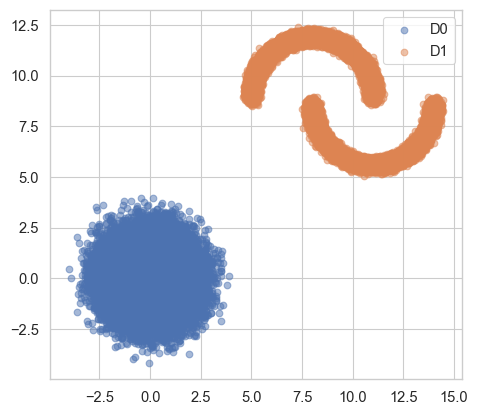

In [182]:
from sklearn.datasets import make_moons
from data_generator import generate_data
#####################################
n_samples = 50000
INPUT_DIM = 3
RANK = 2
CENTER = torch.ones(INPUT_DIM) * 8.0
TYPE = 'two_moons'  # 'low_rank_Gaussian' or 'two_moons'

NUM_STEPS = 200 # Number of time steps for sampling
NUM_SAMPLES = 2000 # Number of samples to Generate
#####################################

pi_0 = dist.MultivariateNormal(torch.zeros(INPUT_DIM, device=device), torch.eye(INPUT_DIM, device=device))
D0 = pi_0.sample([n_samples])  
D1 = generate_data(TYPE, n_samples, INPUT_DIM, RANK, CENTER, device=device)




plt.scatter(D0[:, 0].cpu().numpy(), D0[:, 1].cpu().numpy(), alpha=0.5, label='D0')
plt.scatter(D1[:, 0].cpu().numpy(), D1[:, 1].cpu().numpy(), alpha=0.5, label='D1')
plt.legend()
#plt.xlim(-5, 18)
#plt.ylim(-8, 8)
plt.gca().set_aspect('equal', adjustable='box')
plt.show()


# Generating two moon dataset for training
       


In [181]:
D0.shape, D1.shape

(torch.Size([50000, 3]), torch.Size([50000, 3]))

Epoch [1/10000], loss: 82.7041
Epoch [501/10000], loss: 2.8142
Epoch [1001/10000], loss: 2.3318
Epoch [1501/10000], loss: 2.2932
Epoch [2001/10000], loss: 2.3384
Epoch [2501/10000], loss: 2.4091
Epoch [3001/10000], loss: 2.1455
Epoch [3501/10000], loss: 2.2734
Epoch [4001/10000], loss: 2.1793
Epoch [4501/10000], loss: 2.1492
Epoch [5001/10000], loss: 2.2722
Epoch [5501/10000], loss: 2.2645
Epoch [6001/10000], loss: 2.3278
Epoch [6501/10000], loss: 2.2069
Epoch [7001/10000], loss: 2.2627
Epoch [7501/10000], loss: 2.4633
Epoch [8001/10000], loss: 2.1339
Epoch [8501/10000], loss: 2.1129
Epoch [9001/10000], loss: 2.1528
Epoch [9501/10000], loss: 2.2282


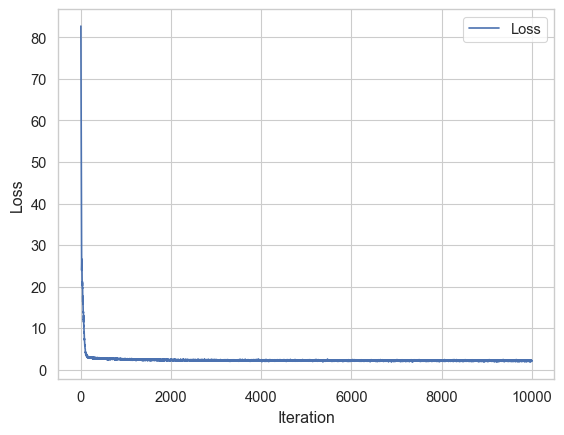

In [183]:
from RFmodules import rf_trainer
from rectified_flow.models.toy_mlp import MLPVelocity
from RFmodules import VelocityNet

straight_rf = RectifiedFlow(
    data_shape=(INPUT_DIM,),
    velocity_field=VelocityNet(INPUT_DIM, h_dim=128).to(device), # MLPVelocity(INPUT_DIM, hidden_sizes = [128] * 6).to(device)
    interp="straight",
    source_distribution=pi_0,
    device=device,
)

losses =rf_trainer(straight_rf, D0, D1, 'loss', num_epochs=10000)
plt.plot(losses, label= 'Loss')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()

In [184]:

euler_sampler_lin = MyEulerSampler(
    rectified_flow=straight_rf,
    time_grid = lin_timegrid_generator(NUM_STEPS),
    num_samples= NUM_SAMPLES,
)

euler_sampler_geom = MyEulerSampler(
    rectified_flow=straight_rf,
    time_grid = geom_timegrid_generator(NUM_STEPS, delta=1/max(INPUT_DIM, NUM_STEPS)),
    num_samples= NUM_SAMPLES,
)



# Sample method 1)
# Will use the default num_steps and num_samples previously set in the Sampler class
traj1_geom = euler_sampler_geom.sample_loop(seed=100)
traj1_lin = euler_sampler_lin.sample_loop(seed=100)


sde_sampler = MynewSDESampler(
    rectified_flow=straight_rf,
    time_grid = MynewSDE_timegrid_generator(NUM_STEPS , c0 = 2, c1 = 5), # 900, c0 = 5, c1 = 10.5
    num_samples= NUM_SAMPLES,
)
traj_sde = sde_sampler.sample_loop(seed=100)


# from rectified_flow.samplers import SDESampler

# sde_sampler_sphere_lin = SDESampler(
#     rectified_flow=straight_rf,
# 	time_grid = lin_timegrid_generator(NUM_STEPS),
# 	num_samples= NUM_SAMPLES,
#     noise_scale = lambda t: 1/(t + 1e-6),
#     noise_method = 'euler',
#     ode_method = 'euler'
# )

# sde_sampler_sphere_geom = SDESampler(
#     rectified_flow=straight_rf,
# 	time_grid = geom_timegrid_generator(NUM_STEPS, delta=1/max(INPUT_DIM, NUM_STEPS)),
# 	num_samples= NUM_SAMPLES,
#     noise_scale = lambda t: 1/(t + 1e-6),
#     noise_method = 'euler',
#     ode_method = 'euler'
# )
# traj2_geom = sde_sampler_sphere_geom.sample_loop(seed=100)
# traj2_lin = sde_sampler_sphere_lin.sample_loop(seed=100)

In [185]:
# visualize the trajectories by tracing the trajectories
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import pandas as pd
from matplotlib.lines import Line2D

def draw_plot_sns(traj, z1, M=5, num_traj = 100, second_coord = 1,sampler_label = 'Deterministic Sampler', save_pdf=True):
    sns.set_theme(
        style="whitegrid",
        context="paper",
        font_scale=1.2
    )

    fig, ax = plt.subplots(figsize=(4.5, 4.5))
    ax.set_xlim(-0.5*M, M)
    ax.set_ylim(-0.5*M, 0.5*M)

    # -------- prepare data --------
    p1 = z1[:900].cpu().numpy() # plot only 900 points from p1 for better visualization
    p0 = traj[0].cpu().numpy()
    gen = traj[-1].cpu().numpy()

    df = pd.DataFrame(
        {
            "x": np.concatenate([p1[:, 0], p0[:, 0], gen[:, 0]]),
            "y": np.concatenate([p1[:, second_coord], p0[:, second_coord], gen[:, second_coord]]),
            "dist": (
                ["$p_1$"] * len(p1)
                + ["$p_0$"] * len(p0)
                + ["Generated"] * len(gen)
            ),
        }
    )

    # -------- seaborn scatter --------
    sns.scatterplot(
        data=df,
        x="x",
        y="y",
        hue="dist",
        alpha=0.35,
        s=20,
        ax=ax,
        legend=False
    )

    # -------- trajectories (matplotlib) --------
    traj_particles = torch.stack(traj).cpu().numpy()
    for i in range(min(num_traj, traj_particles.shape[1])):
        ax.plot(
            traj_particles[:, i, 0],
            traj_particles[:, i, second_coord],
            color="gray",
            alpha=0.15,
            linewidth=0.8
        )

    # -------- opaque legend --------
    palette = sns.color_palette()

    legend_elements = [
        Line2D([0], [0], marker='o', linestyle='',
               label=r'$p_1$', markerfacecolor=palette[0], markersize=8),
        Line2D([0], [0], marker='o', linestyle='',
               label=r'$p_0$', markerfacecolor=palette[1], markersize=8),
        Line2D([0], [0], marker='o', linestyle='',
               label='Generated', markerfacecolor=palette[2], markersize=8),
    ]

    ax.legend(
        handles=legend_elements,
        frameon=True,
        fancybox=True,
        framealpha=0.95,
        loc="upper left"
    )

    ax.set_title(sampler_label, pad=8)
    ax.set_aspect("equal", adjustable="box")
    sns.despine(trim=True)
    plt.tight_layout()
    if save_pdf:
        plt.savefig('assets/two_moon_experiments/' + sampler_label.replace(" ", "_") + '.pdf', format='pdf', bbox_inches='tight', dpi = 300)
    


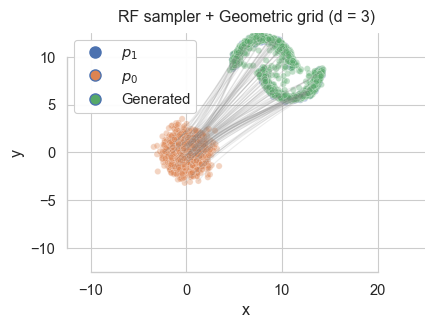

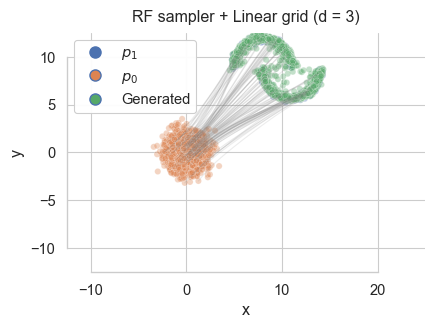

In [175]:
j = 1

fig_geom = draw_plot_sns(traj1_geom.trajectories, D1, second_coord= j, M=25, num_traj=100,
                     sampler_label=f'RF sampler + Geometric grid (d = {INPUT_DIM})', save_pdf=True)
fig_lin = draw_plot_sns(traj1_lin.trajectories, D1, second_coord= j, M=25, num_traj=100,
                     sampler_label=f'RF sampler + Linear grid (d = {INPUT_DIM})', save_pdf=False)

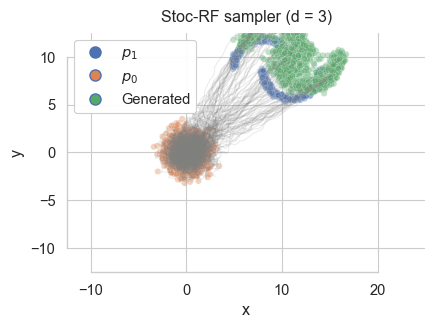

In [186]:
j = 1

fig_sde = draw_plot_sns(traj_sde.trajectories, D1, second_coord= j, M=25, num_traj=100,
                     sampler_label=f'Stoc-RF sampler (d = {INPUT_DIM})', save_pdf=True)


In [103]:
fig_sde

# Trajectorires with True drift

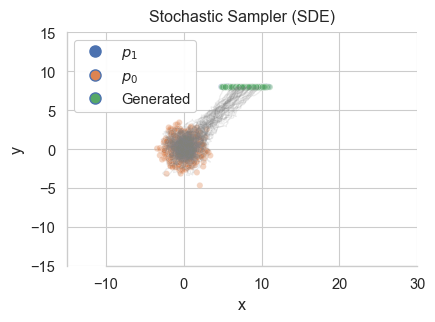

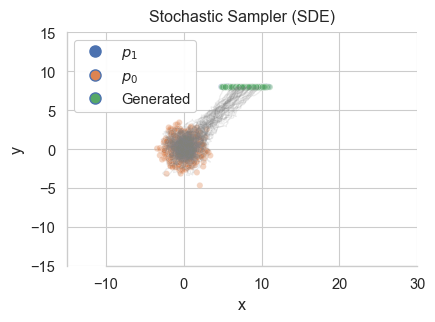

In [87]:
true_euler_sampler_lin = MytrueEulerSampler( k = RANK, d = INPUT_DIM, CENTER= CENTER,
    rectified_flow=straight_rf,
    time_grid = lin_timegrid_generator(NUM_STEPS),
    num_samples= NUM_SAMPLES,
)

true_euler_sampler_geom = MytrueEulerSampler( k = RANK, d = INPUT_DIM, CENTER= CENTER,
    rectified_flow=straight_rf,
    time_grid = geom_timegrid_generator(NUM_STEPS, delta=1/max(INPUT_DIM, NUM_STEPS)),
    num_samples= NUM_SAMPLES,
)

true_sde_sampler = Mynew_trueSDESampler( k = RANK, d = INPUT_DIM, CENTER= CENTER,
    rectified_flow=straight_rf,
    time_grid = MynewSDE_timegrid_generator(200 , c0 = 2, c1 = 5), # 900, c0 = 5, c1 = 10.5
    num_samples= NUM_SAMPLES,
)

true_traj1_geom = true_euler_sampler_geom.sample_loop(seed=100)
true_traj1_lin = true_euler_sampler_lin.sample_loop(seed=100)

true_traj_sde = true_sde_sampler.sample_loop(seed=100)

# fig_geom = draw_plot_sns(true_traj1_geom.trajectories, D1,  second_coord=1, M=30, num_traj=100,
#                      sampler_label='Deterministic Sampler (ODE) + Geometric grid', save_pdf=False)
# fig_lin = draw_plot_sns(true_traj1_lin.trajectories, D1, second_coord=1, M=30, num_traj=100,
#                      sampler_label='Deterministic Sampler (ODE) + Linear grid', save_pdf=False)
fig_sde = draw_plot_sns(true_traj_sde.trajectories, D1,  second_coord=2, M=30, num_traj=50,
                     sampler_label='Stochastic Sampler (SDE)', save_pdf=False)
fig_sde = draw_plot_sns(true_traj_sde.trajectories, D1,  second_coord=2, M=30, num_traj=50,
                     sampler_label='Stochastic Sampler (SDE)', save_pdf=False)

In [27]:
from metric import calculate_discriminative_tv_qda

# --- Example Usage ---

geom_time_grid = geom_timegrid_generator(NUM_STEPS, delta=1/max(INPUT_DIM, NUM_STEPS))
lin_time_grid = lin_timegrid_generator(NUM_STEPS)
pos  = 2  # Position in the time grid to evaluate
blurred_Real_Data_geom = D1[:NUM_SAMPLES] * geom_time_grid[-pos] + D0[:NUM_SAMPLES] * (1 - geom_time_grid[-pos])
blurred_Real_Data_lin = D1[:NUM_SAMPLES] * lin_time_grid[-pos] + D0[:NUM_SAMPLES] * (1 - lin_time_grid[-pos])
blurred_Real_Data_sde = D1[:NUM_SAMPLES] * T[-pos] + D0[:NUM_SAMPLES] * (1 - T[-pos])
blurred_Real_Data_geom = blurred_Real_Data_geom.cpu().numpy()  # Real data samples from distribution p_1
blurred_Real_Data_lin = blurred_Real_Data_lin.cpu().numpy()  # Real data samples from distribution p_1
Gen_Data_geom = true_traj1_geom.trajectories[-pos].cpu().numpy()  # Generated data samples from geometry time grid
Gen_Data_lin = true_traj1_lin.trajectories[-pos].cpu().numpy()  # Generated data samples from linear time grid
Gen_Data_sde = true_traj_sde.trajectories[-pos].cpu().numpy()  # Generated data samples from SDE sampler
tv_qda_geom = calculate_discriminative_tv_qda(blurred_Real_Data_geom, Gen_Data_geom)
tv_qda_lin = calculate_discriminative_tv_qda(blurred_Real_Data_geom, Gen_Data_lin)
tv_qda_sde = calculate_discriminative_tv_qda(blurred_Real_Data_sde, Gen_Data_sde)
print(f"Estimated TV Distance (SDE Sampler): {tv_qda_sde:.4f}")
print(f"Estimated TV Distance (Geometry Time Grid): {tv_qda_geom:.4f}")
print(f"Estimated TV Distance (Linear Time Grid): {tv_qda_lin:.4f}")

Estimated TV Distance (SDE Sampler): 0.0013
Estimated TV Distance (Geometry Time Grid): 0.0055
Estimated TV Distance (Linear Time Grid): 1.0000


In [134]:
geom_time_grid[1], lin_time_grid[1], NUM_STEPS

(tensor(0.0013, dtype=torch.float64), tensor(0.0100), 100)

In [111]:
lin_timegrid_generator(100)

tensor([0.0000, 0.0100, 0.0200, 0.0300, 0.0400, 0.0500, 0.0600, 0.0700, 0.0800,
        0.0900, 0.1000, 0.1100, 0.1200, 0.1300, 0.1400, 0.1500, 0.1600, 0.1700,
        0.1800, 0.1900, 0.2000, 0.2100, 0.2200, 0.2300, 0.2400, 0.2500, 0.2600,
        0.2700, 0.2800, 0.2900, 0.3000, 0.3100, 0.3200, 0.3300, 0.3400, 0.3500,
        0.3600, 0.3700, 0.3800, 0.3900, 0.4000, 0.4100, 0.4200, 0.4300, 0.4400,
        0.4500, 0.4600, 0.4700, 0.4800, 0.4900, 0.5000, 0.5100, 0.5200, 0.5300,
        0.5400, 0.5500, 0.5600, 0.5700, 0.5800, 0.5900, 0.6000, 0.6100, 0.6200,
        0.6300, 0.6400, 0.6500, 0.6600, 0.6700, 0.6800, 0.6900, 0.7000, 0.7100,
        0.7200, 0.7300, 0.7400, 0.7500, 0.7600, 0.7700, 0.7800, 0.7900, 0.8000,
        0.8100, 0.8200, 0.8300, 0.8400, 0.8500, 0.8600, 0.8700, 0.8800, 0.8900,
        0.9000, 0.9100, 0.9200, 0.9300, 0.9400, 0.9500, 0.9600, 0.9700, 0.9800,
        0.9900, 1.0000])

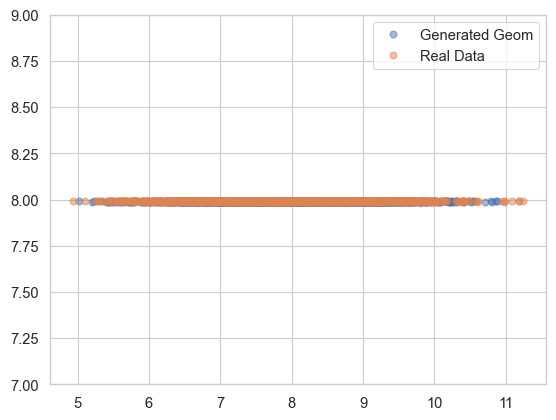

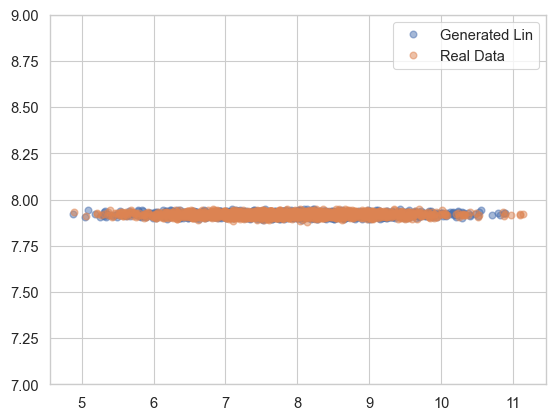

In [139]:
plt.plot(Gen_Data_geom[:,0], Gen_Data_geom[:,9], 'o', alpha=0.5, label='Generated Geom')
plt.plot(blurred_Real_Data_geom[:,0], blurred_Real_Data_geom[:,9], 'o', alpha=0.5, label='Real Data')
plt.legend()
plt.ylim(7, 9)
plt.show()

plt.plot(Gen_Data_lin[:,0], Gen_Data_lin[:,9], 'o', alpha=0.5, label='Generated Lin')
plt.plot(blurred_Real_Data_lin[:,0], blurred_Real_Data_lin[:,9], 'o', alpha=0.5, label='Real Data')
plt.legend()
plt.ylim(7, 9)
plt.show()



In [140]:
# Frobenius norm of covariance matrices
print(f"Frobenius norm of difference between real and generated data cov matrices (Geom): {np.linalg.norm(np.cov(blurred_Real_Data_geom, rowvar=False) - np.cov(Gen_Data_geom, rowvar=False), ord='fro')}")
print(f"Frobenius norm of difference between real and generated data cov matrices (Lin): {np.linalg.norm(np.cov(blurred_Real_Data_lin, rowvar=False) - np.cov(Gen_Data_lin, rowvar=False), ord='fro')}")

Frobenius norm of difference between real and generated data cov matrices (Geom): 0.338139290956576
Frobenius norm of difference between real and generated data cov matrices (Lin): 0.24428006597131383


In [ ]:
# KL distance between Real data and generated data which are gaussian
mean_real_geom = np.mean(blurred_Real_Data_geom, axis=0)
cov_real_geom = np.cov(blurred_Real_Data_geom, rowvar=False)
mean_real_lin = np.mean(blurred_Real_Data_lin, axis=0)
cov_real_lin = np.cov(blurred_Real_Data_lin, rowvar=False)
mean_gen_geom = np.mean(Gen_Data_geom, axis=0)
cov_gen_geom = np.cov(Gen_Data_geom, rowvar=False)
mean_gen_lin = np.mean(Gen_Data_lin, axis=0)
cov_gen_lin = np.cov(Gen_Data_lin, rowvar=False)

from metric import kl_divergence_gaussians

print(f"KL Divergence (Geom): {kl_divergence_gaussians(mean_real_geom, cov_real_geom, mean_gen_geom, cov_gen_geom)}")
print(f"KL Divergence (Lin): {kl_divergence_gaussians(mean_real_lin, cov_real_lin, mean_gen_lin, cov_gen_lin)}")    

KL Divergence (Geom): 733.2103708612062
KL Divergence (Lin): 268.26319044726336


In [84]:
NUM_STEPS

500

In [58]:
np.std(Gen_Data_geom, axis = 0), np.std(Gen_Data_lin, axis = 0)

(array([0.97534955, 0.97153014, 0.9875458 , 1.0015072 , 0.99273103,
        1.0149337 , 0.99619365, 0.9861228 , 0.00198431, 0.00203674],
       dtype=float32),
 array([0.98180854, 0.9779641 , 0.9940864 , 1.00814   , 0.99930555,
        1.0216552 , 1.0027909 , 0.99265337, 0.00198423, 0.00203666],
       dtype=float32))

In [81]:
np.cov(Gen_Data_lin, rowvar=False)

array([[ 1.03485107e+00, -4.84707744e-03, -6.52960652e-03, ...,
        -1.96926049e-05, -5.55568261e-05, -2.82938003e-05],
       [-4.84707744e-03,  1.01036216e+00, -5.05688996e-03, ...,
        -3.29916453e-05,  4.10234280e-05,  6.80117846e-05],
       [-6.52960652e-03, -5.05688996e-03,  9.91930974e-01, ...,
        -6.02760378e-05, -7.23664370e-06,  7.80676446e-05],
       ...,
       [-1.96926049e-05, -3.29916453e-05, -6.02760378e-05, ...,
         4.16147548e-06, -8.82112295e-08,  8.43960562e-08],
       [-5.55568261e-05,  4.10234280e-05, -7.23664370e-06, ...,
        -8.82112295e-08,  3.94523837e-06, -9.53876203e-09],
       [-2.82938003e-05,  6.80117846e-05,  7.80676446e-05, ...,
         8.43960562e-08, -9.53876203e-09,  4.22440109e-06]])

In [82]:
np.cov(Gen_Data_geom, rowvar=False)

array([[ 1.02127929e+00, -4.78377327e-03, -6.44388067e-03, ...,
        -1.95805597e-05, -5.52100426e-05, -2.80930599e-05],
       [-4.78377327e-03,  9.97111461e-01, -4.99063690e-03, ...,
        -3.27728872e-05,  4.07792450e-05,  6.75688557e-05],
       [-6.44388067e-03, -4.99063690e-03,  9.78921319e-01, ...,
        -5.98739794e-05, -7.18086028e-06,  7.75543717e-05],
       ...,
       [-1.95805597e-05, -3.27728872e-05, -5.98739794e-05, ...,
         4.16174033e-06, -8.81479413e-08,  8.44992050e-08],
       [-5.52100426e-05,  4.07792450e-05, -7.18086028e-06, ...,
        -8.81479413e-08,  3.94556903e-06, -9.54176246e-09],
       [-2.80930599e-05,  6.75688557e-05,  7.75543717e-05, ...,
         8.44992050e-08, -9.54176246e-09,  4.22474078e-06]])

In [162]:
#np.cov(Real_Data, rowvar=False)
d = 256 * 256; N = 80
d**2/N**10

4e-10